# 04 — BAMIC wine prior-sensitivity (Dr. Cao, Point 3 — OPTIONAL)

**Scope note:** Raanju asked for Points 1 and 4 only. Codex nevertheless ran a
prior-sensitivity study; this notebook lets you reproduce that experiment in
the **official pipeline** if you and Raanju decide to include it. Skip it
otherwise.

Design: three runs at the matched seed **20260526**, priors
$\mathcal N(0, 0.5^2)$, $\mathcal N(0, 1)$, $\mathcal N(0, 2^2)$ on both
Bayesian heads, run labels `prior0p5 / prior1p0 / prior2p0`. Everything else
identical. The `1.0` run is repeated (rather than reusing the frozen `_v1`) so
all three carry identical add-on outputs.

Two facts to keep in mind when interpreting a null result here (both visible
in the outputs): the ELBO scales the KL term by $1/N_{\mathrm{train}}$
($N=25{,}000$), so the prior is weakly informative *by design*; and the
variational SDs are initialized at softplus$(-5)\approx 0.0067$ — if fitted
posterior SDs sit at that value across all priors, the "insensitivity" partly
reflects initialization, not only data dominance. Codex's reported mean
parameter posterior SD (0.00698, identical across priors) is essentially the
initialization value — check whether the official pipeline reproduces that.

In [1]:

# ================================================================
# 0. Mount Drive and locate files. Notebooks stay on YOUR computer,
# same as your usual workflow: open this notebook in Colab from your
# local folder; only data/outputs live in Drive. If the official 01d
# notebook is needed and not already in this Colab session, a file
# picker opens so you can choose it from your local folder.
# If anything is guessed wrong, set NOTEBOOK_PATH and/or OUTPUTS_ROOT
# manually below and rerun this cell.
# ================================================================
import os
from pathlib import Path

REQUIRE_OFFICIAL_NB = True   # this notebook needs the 01d file itself

try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('[note] not on Colab — set paths manually below.')

MYDRIVE = Path('/content/drive/MyDrive')
NOTEBOOK_PATH = None   # manual override, e.g. '/content/01d_bamic_wine_gatefix_bestval.ipynb'
OUTPUTS_ROOT = None    # manual override, e.g. '/content/drive/MyDrive/AMIC project/wine_benchmark/outputs'

OFFICIAL_NB = '01d_bamic_wine_gatefix_bestval.ipynb'
_PRUNE = {'drive', 'sample_data', '.config'}

def _walk_find(match, roots, max_depth=5, want_dir=False):
    """Bounded filename search, skipping hidden dirs and the Drive mount."""
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        base = str(root).rstrip('/').count('/')
        for dirpath, dirnames, filenames in os.walk(root):
            if dirpath.count('/') - base >= max_depth:
                dirnames[:] = []
                continue
            dirnames[:] = [d for d in dirnames
                           if not d.startswith('.') and d not in _PRUNE]
            names = dirnames if want_dir else filenames
            for n in names:
                if match(n):
                    return Path(dirpath) / n
    return None

if REQUIRE_OFFICIAL_NB and NOTEBOOK_PATH is None:
    # 1) already in this Colab session (drag-dropped into the Files panel,
    #    or uploaded on a previous run of this cell)
    for _cand in [Path('/content') / OFFICIAL_NB, Path.cwd() / OFFICIAL_NB]:
        if _cand.exists():
            NOTEBOOK_PATH = _cand
            break
    if NOTEBOOK_PATH is None:
        NOTEBOOK_PATH = _walk_find(lambda n: n == OFFICIAL_NB,
                                   [Path('/content')], max_depth=3)
    # 2) a copy kept in Drive (optional)
    if NOTEBOOK_PATH is None:
        _guess = MYDRIVE / 'AMIC project' / 'wine_benchmark' / OFFICIAL_NB
        NOTEBOOK_PATH = _guess if _guess.exists() else _walk_find(
            lambda n: n == OFFICIAL_NB, [MYDRIVE / 'AMIC project', MYDRIVE])
    # 3) pick it from your local computer (your normal upload workflow)
    if NOTEBOOK_PATH is None and ON_COLAB:
        print(f'{OFFICIAL_NB} is not in this session or Drive.')
        print('Choose it from your local folder, e.g. '
              'BAMIC_code/dr_cao_multiseed/ or '
              'BAMIC_code/BAMIC_codex_updated/wine_benchmark/:')
        from google.colab import files
        _up = files.upload()
        for _name in _up:
            if '01d_bamic_wine_gatefix_bestval' in _name and _name.endswith('.ipynb'):
                NOTEBOOK_PATH = Path('/content') / _name

if REQUIRE_OFFICIAL_NB:
    assert NOTEBOOK_PATH is not None and Path(NOTEBOOK_PATH).exists(), (
        f'Could not obtain {OFFICIAL_NB}. Rerun this cell and choose the file '
        f'in the upload dialog, or set NOTEBOOK_PATH manually above.')
    NOTEBOOK_PATH = str(NOTEBOOK_PATH)
    print('NOTEBOOK_PATH:', NOTEBOOK_PATH)

if OUTPUTS_ROOT is None:
    _guess = MYDRIVE / 'AMIC project' / 'wine_benchmark' / 'outputs'
    if _guess.exists() and any(_guess.glob('wine_bamic_*')):
        OUTPUTS_ROOT = _guess
    else:
        _hit = _walk_find(lambda n: n.startswith('wine_bamic_'),
                          [MYDRIVE / 'AMIC project', MYDRIVE], want_dir=True)
        OUTPUTS_ROOT = _hit.parent if _hit is not None else _guess
OUTPUTS_ROOT = Path(OUTPUTS_ROOT)
OUTPUTS_ROOT.mkdir(parents=True, exist_ok=True)
print('OUTPUTS_ROOT :', OUTPUTS_ROOT)
_existing = sorted(p.name for p in OUTPUTS_ROOT.glob('wine_bamic_*'))
print(f'existing wine_bamic_* run folders here: {len(_existing)}')
for _n in _existing[:8]:
    print('  ', _n)
if not _existing:
    print('  [check] none found — if runs exist elsewhere, set OUTPUTS_ROOT '
          'manually above. (For a first-ever run this is fine.)')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NOTEBOOK_PATH: /content/drive/MyDrive/AMIC project/dr_cao_multiseed/01d_bamic_wine_gatefix_bestval.ipynb
OUTPUTS_ROOT : /content/drive/MyDrive/AMIC project/wine_benchmark/outputs
existing wine_bamic_* run folders here: 15
   wine_bamic_frozen_ep10_heads1_lamB0p1_lamS0p01_len100
   wine_bamic_frozen_ep15_heads1_lamB0p1_lamS0p01_len100
   wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_ms1
   wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_v1
   wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260527_ms1
   wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260528_ms1
   wine_

In [2]:
# ================================================================
# 1. Configuration
# ================================================================
PRIOR_SEED = 20260526
PRIOR_RUNS = [('prior0p5', 0.5), ('prior1p0', 1.0), ('prior2p0', 2.0)]
SEEDS_PLAN = [20260526, 20260527, 20260528, 20260529, 20260530,
              20260531, 20260532, 20260533, 20260534, 20260535]

SAVE_TEST_DRAWS = False    # not needed for the prior comparison
RUN_TOKEN_PANEL = True     # token CI widths across priors
PANEL_SIZE = 200
PANEL_MC = 100

REQUIRED = ['final_metrics.csv', 'test_document_uncertainty.csv',
            'example_word_uncertainty.csv', 'run_config.csv',
            'param_posterior_sd.csv', 'panel_word_uncertainty.csv']

In [3]:

# ================================================================
# Extraction + patch machinery.
# The official notebook is read from Drive and lightly patched.
# Every patch asserts it matched exactly the expected number of
# times, so any drift in the official notebook fails loudly here.
# ================================================================
import json, re, gc, hashlib, traceback
from pathlib import Path

def extract_code(nb_path):
    """Concatenate the official notebook's code cells, dropping magics."""
    raw = Path(nb_path).read_text()
    print('notebook sha256:', hashlib.sha256(raw.encode()).hexdigest()[:16])
    nb = json.loads(raw)
    chunks = []
    for cell in nb['cells']:
        if cell['cell_type'] != 'code':
            continue
        src = ''.join(cell['source'])
        lines = []
        for l in src.splitlines():
            if l.lstrip().startswith(('!', '%')):
                continue                      # shell/magic line
            m = re.match(r'^(\s*)(\w+)\s*=\s*!', l)
            if m:                             # shell capture, e.g. x = !nvidia-smi
                lines.append(f'{m.group(1)}{m.group(2)} = []  '
                             f'# shell capture stubbed by driver')
                continue
            lines.append(l)
        chunks.append('\n'.join(lines))
    return '\n\n# ===== CELL =====\n\n'.join(chunks)

def sub1(src, pattern, repl, expect=1, flags=0):
    out, n = re.subn(pattern, repl, src, flags=flags)
    assert n == expect, f'pattern {pattern!r} matched {n}x, expected {expect}'
    return out

def patch_seed_plan(src, seeds):
    plan = 'MATCHED_SEED_PLAN = [' + ', '.join(str(s) for s in seeds) + ']'
    return sub1(src, r'MATCHED_SEED_PLAN\s*=\s*\[[^\]]*\]', plan, flags=re.S)

def patch_run(src, seed, run_label):
    src = sub1(src, r'(?m)^RUN_SEED\s*=\s*\d+', f'RUN_SEED = {seed}')
    src = sub1(src, r"(?m)^RUN_LABEL\s*=\s*'[^']*'", f"RUN_LABEL = '{run_label}'")
    return src

def patch_prior(src, prior_sd):
    """Route both Bayesian heads' prior SD through one injected constant."""
    src = f'PRIOR_SD = {prior_sd}\n' + src
    src = sub1(src, r'prior_sigma_b=1\.0', 'prior_sigma_b=PRIOR_SD', expect=2)
    src = sub1(src, r'prior_sigma_beta=1\.0', 'prior_sigma_beta=PRIOR_SD', expect=2)
    return src

def find_run_folder(outputs_root, seed, run_label):
    hits = sorted(Path(outputs_root).glob(f'*seed{seed}_{run_label}'))
    assert len(hits) <= 1, f'multiple folders for seed {seed} {run_label}: {hits}'
    return hits[0] if hits else None

def folder_complete(folder, required):
    return folder is not None and all((folder / f).exists() for f in required)

def run_patched(source, tag, script_dir):
    """Save the patched script for provenance, then exec it fresh."""
    script_dir = Path(script_dir); script_dir.mkdir(parents=True, exist_ok=True)
    script_path = script_dir / f'seed_run_{tag}.py'
    script_path.write_text(source)
    print(f'--- executing {script_path.name} ({len(source)} chars) ---')
    ns = {'__name__': '__main__'}
    exec(compile(source, str(script_path), 'exec'), ns)
    return ns

def cleanup_after_run(ns):
    import matplotlib.pyplot as plt
    plt.close('all')
    ns.clear()
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


In [4]:
ADDON_TEMPLATE = r'''

# ================================================================
# MULTISEED ADD-ON (appended by the driver; not part of official 01d)
# Saves (a) the full matrix of test posterior-predictive draws,
# (b) word-level posterior summaries for a fixed panel of test
# documents, and (c) the fitted variational posterior SDs.
# All outputs go into the same OUTPUT_DIR as the official artifacts.
# ================================================================
import numpy as _np
import pandas as _pd
import torch as _torch
import torch.nn.functional as _F

SAVE_TEST_DRAWS = __SAVE_TEST_DRAWS__
RUN_TOKEN_PANEL = __RUN_TOKEN_PANEL__
PANEL_SIZE = __PANEL_SIZE__
PANEL_MC = __PANEL_MC__

if SAVE_TEST_DRAWS:
    # One extra posterior-predictive pass over the test loader, keeping
    # the raw [n_samples, n_docs] probability draws this time.
    _unc_addon, _prob_samples = posterior_predict_loader(
        model, test_loader, n_samples=FINAL_MC_SAMPLES)
    _np.save(OUTPUT_DIR / 'test_prob_samples.npy',
             _prob_samples.astype(_np.float32))
    _unc_addon.to_csv(OUTPUT_DIR / 'test_document_uncertainty_addon.csv',
                      index=False)
    print('addon: saved test_prob_samples.npy', _prob_samples.shape)

if RUN_TOKEN_PANEL:
    # Word-level posterior summaries for the first PANEL_SIZE test
    # documents (fixed panel, identical across seeds because the test
    # split is fixed on disk). Mirrors the section-17 example logic,
    # batched over documents.
    _n_panel = int(min(PANEL_SIZE, x_test.shape[0]))
    _ids = _torch.tensor(x_test[:_n_panel], dtype=_torch.long)
    _z_all = _np.zeros((PANEL_MC, _n_panel, MAX_LEN), dtype=_np.float32)
    _d_all = _np.zeros_like(_z_all)
    model.eval()
    with _torch.no_grad():
        for _s in range(PANEL_MC):
            for _start in range(0, _n_panel, BATCH_SIZE):
                _bb = _ids[_start:_start + BATCH_SIZE].to(DEVICE)
                _out = model(_bb, sample=True)
                _z_all[_s, _start:_start + _bb.shape[0]] = _out['word_logit'].cpu().numpy()
                _d_all[_s, _start:_start + _bb.shape[0]] = _out['delta'].cpu().numpy()
    _rows = []
    for _i in range(_n_panel):
        _L = int(len_test[_i])
        for _j in range(_L):
            _zs = _z_all[:, _i, _j]
            _ds = _d_all[:, _i, _j]
            _rows.append({
                'doc_index': _i,
                'position': _j,
                'word': id_to_word.get(int(x_test[_i, _j]), '<UNK>'),
                'y_true': int(test_df['y'].iloc[_i]),
                'z_mean': float(_zs.mean()),
                'z_sd': float(_zs.std()),
                'z_ci95_lo': float(_np.quantile(_zs, 0.025)),
                'z_ci95_hi': float(_np.quantile(_zs, 0.975)),
                'p_z_positive': float((_zs > 0).mean()),
                'delta_mean': float(_ds.mean()),
                'delta_sd': float(_ds.std()),
            })
    _pd.DataFrame(_rows).to_csv(OUTPUT_DIR / 'panel_word_uncertainty.csv',
                                index=False)
    print(f'addon: saved panel_word_uncertainty.csv '
          f'({_n_panel} docs, {len(_rows)} token rows)')

# Fitted variational posterior SDs of every BayesianLinear module,
# with the initialization value for comparison (init_rho = -5.0 gives
# softplus(-5) ~= 0.00672; posterior SDs that stay at this value have
# not moved from initialization).
_sd_rows = []
for _mod_name, _mod in model.named_modules():
    if _mod.__class__.__name__ == 'BayesianLinear':
        _w = _F.softplus(_mod.weight_rho).detach().cpu().numpy().ravel()
        _b = _F.softplus(_mod.bias_rho).detach().cpu().numpy().ravel()
        _all = _np.concatenate([_w, _b])
        _sd_rows.append({
            'module': _mod_name,
            'n_params': int(_all.size),
            'mean_posterior_sd': float(_all.mean()),
            'median_posterior_sd': float(_np.median(_all)),
            'min_posterior_sd': float(_all.min()),
            'max_posterior_sd': float(_all.max()),
            'init_sd_from_init_rho': float(_np.log1p(_np.exp(-5.0))),
            'prior_sigma': float(_mod.prior_sigma.item()),
        })
_pd.DataFrame(_sd_rows).to_csv(OUTPUT_DIR / 'param_posterior_sd.csv', index=False)
print('addon: saved param_posterior_sd.csv')
'''

def addon_source():
    return (ADDON_TEMPLATE
            .replace('__SAVE_TEST_DRAWS__', str(bool(SAVE_TEST_DRAWS)))
            .replace('__RUN_TOKEN_PANEL__', str(bool(RUN_TOKEN_PANEL)))
            .replace('__PANEL_SIZE__', str(PANEL_SIZE))
            .replace('__PANEL_MC__', str(PANEL_MC)))
print('addon length:', len(addon_source()), 'chars')

addon length: 4220 chars


notebook sha256: 86fa7bb32d48ee23

########## PRIOR 0.5 (prior0p5) ##########
--- executing seed_run_20260526_prior0p5.py (93777 chars) ---

Your runtime has 179.4 gigabytes of available RAM
Using device: cuda
RUN_SEED: 20260526
MATCHED_SEED_PLAN: [20260526, 20260527, 20260528, 20260529, 20260530, 20260531, 20260532, 20260533, 20260534, 20260535]
RUN_MODE                : gate_calibrated_selnorm
RUN_SEED / RUN_LABEL    : 20260526 / prior0p5
FREEZE_EMBEDDINGS       : True
ABLATION_EPOCHS         : 15
NUM_HEADS               : 1
LAMBDA_BOILERPLATE      : 0.1
LAMBDA_STOPWORD         : 0.01
STOPWORD_WARMUP_EPOCHS  : 2
BAMIC_LEARNING_RATE     : 0.0003
MAX_LEN / BATCH_SIZE    : 100 / 128
POSITION_ENCODING       : learned_absolute | enabled: True
AGGREGATION_MODE        : selected_token_mean
LAMBDA_P1 / P2 / P3     : 0.01 / 0.0 / 0.001
SELECTION_RATE_BAND     : (0.075, 0.125) | lambda: 1.0 | enabled: True
GATE CHECKPOINT         : True | mean-rate envelope: (0.05, 0.15) | max low/high documen

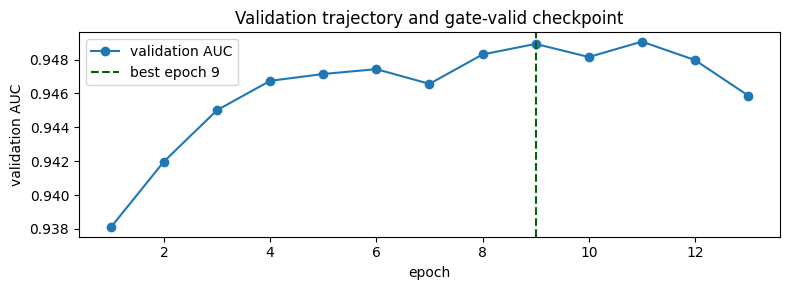

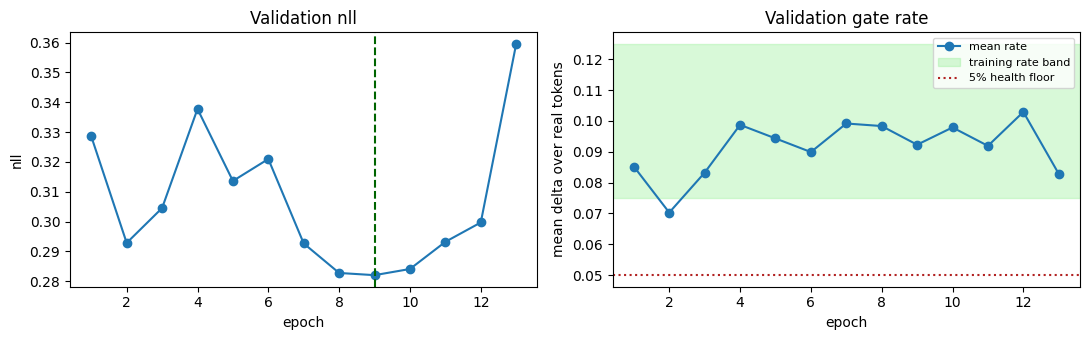

Restored epoch 9: validation nll=0.282041
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,3.022931,0.092650,0.072122,0.092360,0.114118,0.021781,3.022932,0.464596,0.00212,0.077760,0.00792
1,valid,3.022878,0.092573,0.072873,0.092536,0.112760,0.031666,3.022878,0.791654,0.00200,0.069667,0.00700
2,test,3.019827,0.092694,0.072362,0.092283,0.114246,0.019644,3.019828,0.491106,0.00100,0.075300,0.00800


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,3.013391,0.092356,0.071959,0.092075,0.113765,0.0022,0.000520,3.013392,0.464468,...,0.270348,0.000311,0.259643,2.247544,2.736216,0.154264,25000,True,eligible,False
1,valid,3.013851,0.092303,0.072636,0.092221,0.112417,0.0020,0.000667,3.013852,0.788222,...,0.270035,0.000224,0.258741,2.262564,2.725756,0.153310,3000,True,eligible,True
2,test,3.010253,0.092400,0.072165,0.092078,0.113846,0.0010,0.000900,3.010254,0.491532,...,0.271205,0.000285,0.259727,2.246212,2.741132,0.154684,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.6
Best validation-F1 threshold      : 0.425
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


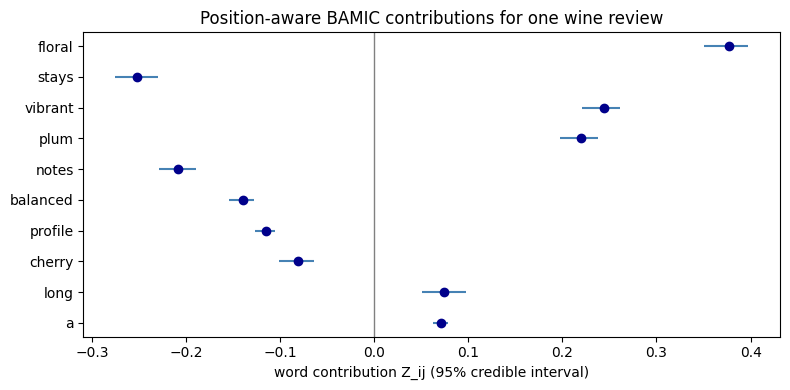

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.8888, 'f1': 0.8445, 'auc': np.float64(0.9598), 'brier': np.float64(0.0785), 'nll': 0.2503} ece= 0.0336
valid {'acc': 0.8723, 'f1': 0.8206, 'auc': np.float64(0.9489), 'brier': np.float64(0.0897), 'nll': 0.282} ece= 0.0332
test {'acc': 0.8732, 'f1': 0.8237, 'auc': np.float64(0.9498), 'brier': np.float64(0.0882), 'nll': 0.2796} ece= 0.0343
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_prior0p5
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] prior0p5

########## PRIOR 1.0 (prior1p0) ##########
--- executing seed_run_20260526_prior1p0.py (93777 chars) ---

Your runtime has 179.4 gigabytes of available RAM
Using device: cuda
RUN_SEED: 

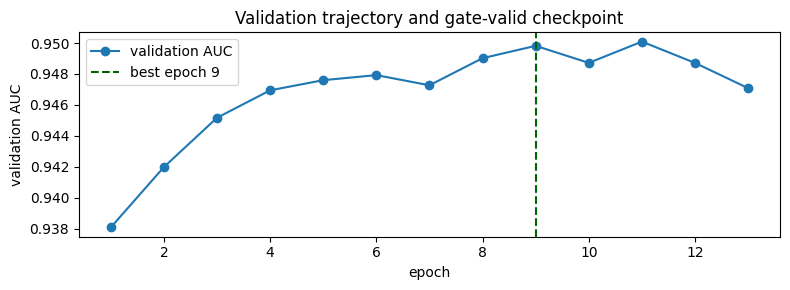

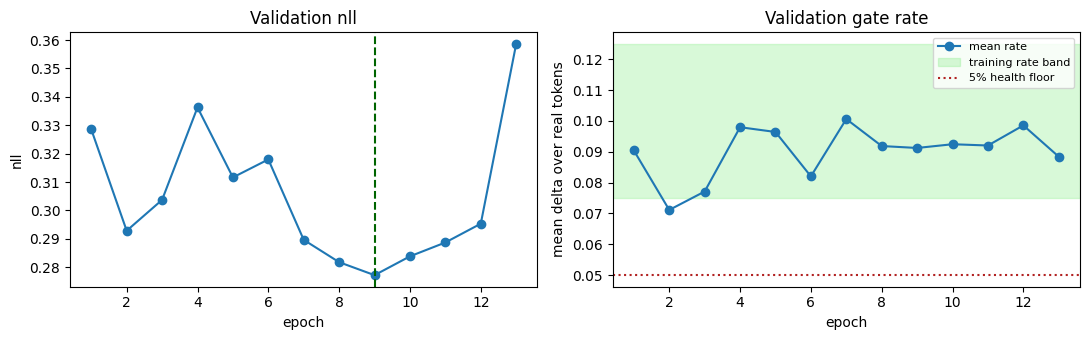

Restored epoch 9: validation nll=0.277218
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,2.987437,0.091607,0.069042,0.089755,0.120178,0.033158,2.987438,0.550270,0.0006,0.1250,0.03384
1,valid,2.986299,0.091462,0.070048,0.089716,0.119454,0.051267,2.986300,0.675858,0.0000,0.1180,0.03300
2,test,2.983014,0.091584,0.069168,0.089728,0.120026,0.040724,2.983015,0.713337,0.0009,0.1249,0.03190


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,2.978432,0.091330,0.068857,0.089482,0.119974,0.0006,0.004720,2.978433,0.550786,...,0.365087,0.001365,0.301460,2.629568,3.198137,0.190364,25000,True,eligible,False
1,valid,2.979261,0.091250,0.069795,0.089453,0.119561,0.0000,0.003667,2.979262,0.666440,...,0.366570,0.001344,0.300868,2.641073,3.193569,0.190284,3000,True,eligible,True
2,test,2.972073,0.091247,0.068860,0.089368,0.119661,0.0009,0.004400,2.972074,0.700344,...,0.363305,0.001250,0.300559,2.632560,3.201088,0.190328,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.53
Best validation-F1 threshold      : 0.455
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


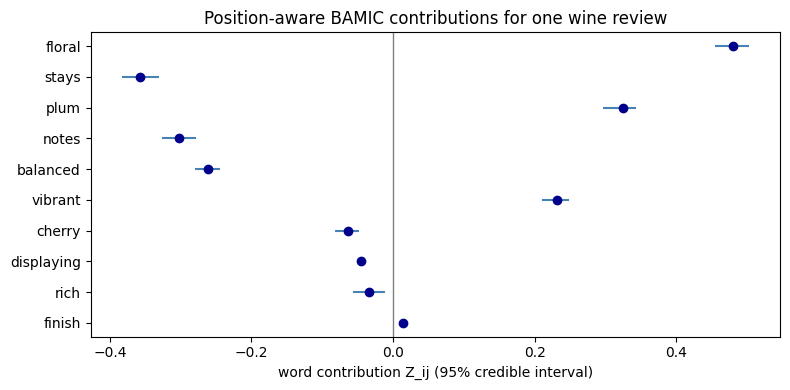

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.893, 'f1': 0.8487, 'auc': np.float64(0.9617), 'brier': np.float64(0.0756), 'nll': 0.242} ece= 0.0267
valid {'acc': 0.875, 'f1': 0.8227, 'auc': np.float64(0.9498), 'brier': np.float64(0.0879), 'nll': 0.2772} ece= 0.0292
test {'acc': 0.8749, 'f1': 0.8243, 'auc': np.float64(0.9505), 'brier': np.float64(0.0869), 'nll': 0.2757} ece= 0.0278
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_prior1p0
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] prior1p0

########## PRIOR 2.0 (prior2p0) ##########
--- executing seed_run_20260526_prior2p0.py (93777 chars) ---

Your runtime has 179.4 gigabytes of available RAM
Using device: cuda
RUN_SEED: 20

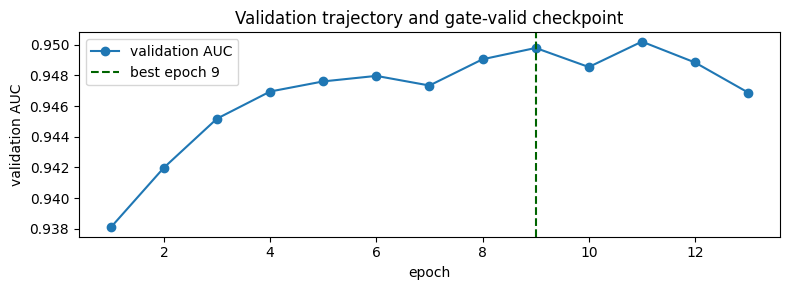

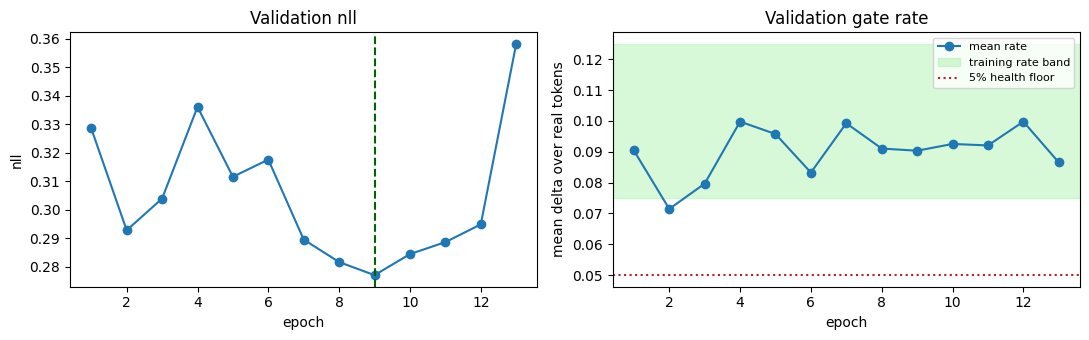

Restored epoch 9: validation nll=0.277129
Restored validation gate: eligible
test: (10000, 3) | positive rate: 0.342
test batches: 79
The restored checkpoint will now be evaluated on the existing exploratory comparison split.
Posterior selection/denominator diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,selection_rate_min,aggregation_denominator_mean,aggregation_denominator_min,fraction_selection_rate_below_floor,fraction_selection_rate_below_training_band,fraction_selection_rate_above_training_band
0,train,2.957679,0.090689,0.068004,0.088788,0.119776,0.034134,2.957680,0.541182,0.00072,0.14236,0.032240
1,valid,2.957302,0.090569,0.068818,0.088740,0.119234,0.050124,2.957302,0.631667,0.00000,0.13300,0.033667
2,test,2.952734,0.090652,0.068202,0.088797,0.119194,0.041110,2.952734,0.689452,0.00110,0.14270,0.031000


Deterministic token-level gate diagnostics:


,split,selected_mass_mean,selection_rate_mean,selection_rate_q05,selection_rate_median,selection_rate_q95,fraction_docs_below_gate_health_min,fraction_docs_above_gate_health_max,aggregation_denominator_mean,aggregation_denominator_min,...,delta_token_q99,fraction_tokens_delta_ge_0p5,mean_doc_max_delta,gate_contrast_ratio_p10,gate_contrast_ratio_median,gate_max_minus_mean_median,gate_contrast_documents,passes_preregistered_gate_health,gate_health_reason,used_for_checkpoint_selection
0,train,2.948910,0.090419,0.067842,0.088503,0.119354,0.00072,0.004480,2.948911,0.541771,...,0.364989,0.001648,0.302841,2.657275,3.233336,0.190980,25000,True,eligible,False
1,valid,2.950317,0.090359,0.068549,0.088381,0.119073,0.00000,0.003333,2.950318,0.623038,...,0.367672,0.001558,0.302347,2.668621,3.219974,0.190968,3000,True,eligible,True
2,test,2.942668,0.090343,0.067948,0.088553,0.118844,0.00110,0.004700,2.942669,0.682494,...,0.363891,0.001442,0.301765,2.658169,3.232658,0.190848,10000,True,eligible,False


Interpret delta as a soft gate score. Passing these diagnostics does not make it a calibrated human-rationale probability.
Best validation-accuracy threshold: 0.53
Best validation-F1 threshold      : 0.45
Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


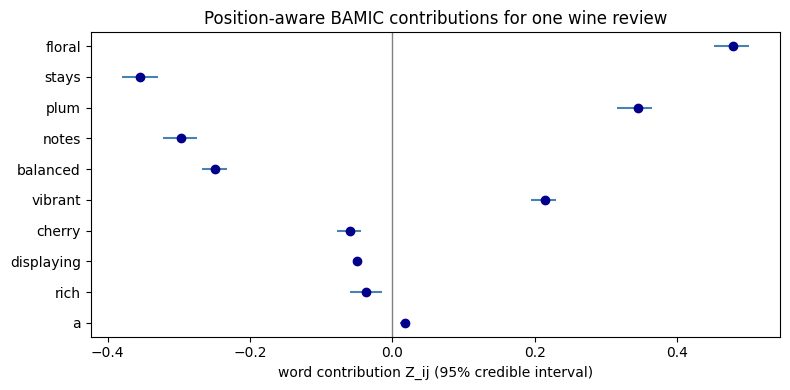

Stopword contamination in top-100 corpus words: 0
train {'acc': 0.8933, 'f1': 0.849, 'auc': np.float64(0.9618), 'brier': np.float64(0.0755), 'nll': 0.2416} ece= 0.0264
valid {'acc': 0.875, 'f1': 0.8229, 'auc': np.float64(0.9498), 'brier': np.float64(0.0879), 'nll': 0.2771} ece= 0.0282
test {'acc': 0.8747, 'f1': 0.8238, 'auc': np.float64(0.9504), 'brier': np.float64(0.0869), 'nll': 0.2756} ece= 0.0274
Saved metrics, gate diagnostics, run configuration, checkpoint provenance, and best weights to:
/content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_gatefix_rate0p075to0p125_posenc_selnorm_gatevalid_bestval_frozen_ep15_heads1_lamB0p1_lamS0p01_len100_seed20260526_prior2p0
addon: saved panel_word_uncertainty.csv (200 docs, 6579 token rows)
addon: saved param_posterior_sd.csv
[done] prior2p0


In [5]:
# ================================================================
# 2. Run loop — three prior runs at the matched seed
# ================================================================
base_source = extract_code(NOTEBOOK_PATH)
script_dir = Path(OUTPUTS_ROOT) / '_prior_driver_scripts'

for run_label, prior_sd in PRIOR_RUNS:
    folder = find_run_folder(OUTPUTS_ROOT, PRIOR_SEED, run_label)
    if folder_complete(folder, REQUIRED):
        print(f'[skip] {run_label}: complete at {folder.name}')
        continue
    if folder is not None:
        print(f'[WARN] {run_label}: folder exists but incomplete — move it '
              f'aside in Drive and rerun. Skipping.')
        continue
    src = patch_seed_plan(base_source, SEEDS_PLAN)
    src = patch_run(src, PRIOR_SEED, run_label)
    src = patch_prior(src, prior_sd)
    src = src + addon_source()
    print(f'\n########## PRIOR {prior_sd} ({run_label}) ##########')
    try:
        ns = run_patched(src, f'{PRIOR_SEED}_{run_label}', script_dir)
    except Exception:
        traceback.print_exc()
        print(f'[STOP] {run_label} failed — fix before continuing.')
        break
    cleanup_after_run(ns)
    print(f'[done] {run_label}')

In [6]:
# ================================================================
# 3. Prior-sensitivity comparison table (mirrors Codex's section 4)
# ================================================================
import numpy as np
import pandas as pd

rows = []
for run_label, prior_sd in PRIOR_RUNS:
    folder = find_run_folder(OUTPUTS_ROOT, PRIOR_SEED, run_label)
    if not folder_complete(folder, REQUIRED):
        print(f'[skip] {run_label} incomplete'); continue
    fm = pd.read_csv(folder / 'final_metrics.csv')
    t = fm[fm['split'] == 'test'].iloc[0]
    docs = pd.read_csv(folder / 'test_document_uncertainty.csv')
    panel = pd.read_csv(folder / 'panel_word_uncertainty.csv')
    psd = pd.read_csv(folder / 'param_posterior_sd.csv')
    cfg = pd.read_csv(folder / 'run_config.csv').iloc[0]
    tau = float(cfg['best_acc_threshold'])
    lo, hi, p, y = (docs['ci95_lo'].to_numpy(), docs['ci95_hi'].to_numpy(),
                    docs['p_mean'].to_numpy(), docs['y_true'].to_numpy())
    auto = (lo > tau) | (hi < tau)
    w = psd['n_params'].to_numpy(); m = psd['mean_posterior_sd'].to_numpy()
    rows.append({
        'prior_sd': prior_sd,
        'mean_param_posterior_sd': float((w * m).sum() / w.sum()),
        'median_doc_ci_width': float(docs['ci_width'].median()),
        'median_token_ci_width': float(
            (panel['z_ci95_hi'] - panel['z_ci95_lo']).median()),
        'acc': float(t['acc']), 'auc': float(t['auc']),
        'nll': float(t['nll']), 'ece': float(t['ece']),
        'routing_coverage_tuned_tau': float(auto.mean()),
        'best_epoch': int(t['best_epoch']),
    })
prior_table = pd.DataFrame(rows)
out_dir = Path(OUTPUTS_ROOT) / 'prior_sensitivity_results'
out_dir.mkdir(exist_ok=True)
prior_table.to_csv(out_dir / 'prior_sensitivity_summary.csv', index=False)
print(prior_table.to_string(index=False))
print(f"\ninit posterior SD softplus(-5) = {np.log1p(np.exp(-5.0)):.5f} "
      f"— compare with mean_param_posterior_sd above.")
print("Codex reported (reimplementation): 0.006984 / 0.006978 / 0.006987")

 prior_sd  mean_param_posterior_sd  median_doc_ci_width  median_token_ci_width    acc      auc      nll      ece  routing_coverage_tuned_tau  best_epoch
      0.5                 0.007434             0.015232               0.002254 0.8732 0.949830 0.279601 0.034256                      0.9653           9
      1.0                 0.007475             0.014376               0.001745 0.8749 0.950469 0.275693 0.027788                      0.9673           9
      2.0                 0.007476             0.014416               0.001779 0.8747 0.950436 0.275644 0.027417                      0.9679           9

init posterior SD softplus(-5) = 0.00672 — compare with mean_param_posterior_sd above.
Codex reported (reimplementation): 0.006984 / 0.006978 / 0.006987
